In [35]:
import pandas as pd

df = pd.read_excel("dataset/Online Retail.xlsx", engine="openpyxl")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [36]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert data types
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")

# Remove missing Customer IDs
df = df.dropna(subset=["CustomerID"])

# Keep only valid purchases
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid dates
df = df.dropna(subset=["InvoiceDate"])

# Calculate total purchase value
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("Cleaning completed successfully!")
print("Final shape:", df.shape)

df.head()

Cleaning completed successfully!
Final shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [37]:
# Set reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print("RFM analysis completed!")
print("Number of customers:", len(rfm))

rfm.head()

RFM analysis completed!
Number of customers: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [38]:
# Descriptive statistics of RFM features

print("RFM Descriptive Statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

RFM Descriptive Statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


In [39]:
print("\nAverage Purchase Value:", df["TotalPrice"].mean())
print("Average Purchase Frequency:", rfm["Frequency"].mean())
print("Average Customer Lifetime Value:", rfm["Monetary"].mean())


Average Purchase Value: 22.396999889415003
Average Purchase Frequency: 4.272014753342554
Average Customer Lifetime Value: 2054.2664601198708


In [40]:
from sklearn.preprocessing import StandardScaler

# Select RFM features
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM data standardized successfully!")
print("Scaled data shape:", rfm_scaled.shape)

rfm_scaled[:5]

RFM data standardized successfully!
Scaled data shape: (4338, 3)


array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

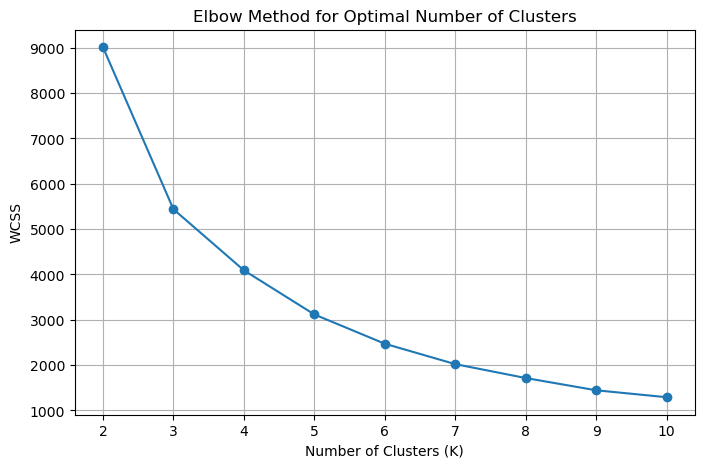

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for different numbers of clusters
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [42]:
# Apply K-Means clustering

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Assign each customer to a cluster
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("Number of clusters:", optimal_k)

rfm.head()

K-Means clustering completed successfully!
Number of clusters: 4


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [43]:
# Analyze each customer cluster

cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

print("Customer Cluster Profile:")
cluster_profile.round(2)

Customer Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


In [44]:
# Count customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


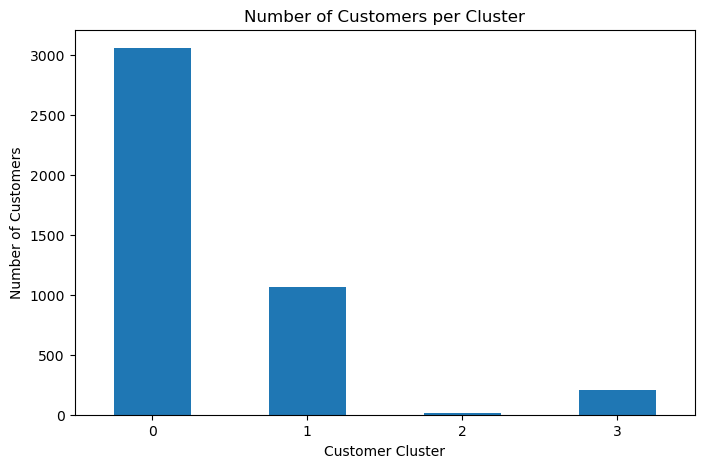

In [45]:
# Visualize number of customers in each cluster

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

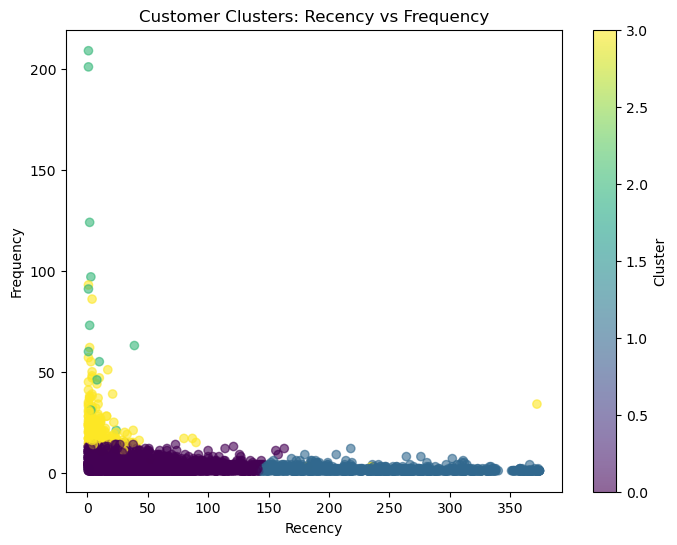

In [46]:
# Recency vs Frequency

plt.figure(figsize=(8, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Clusters: Recency vs Frequency")
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.colorbar(label="Cluster")

plt.show()

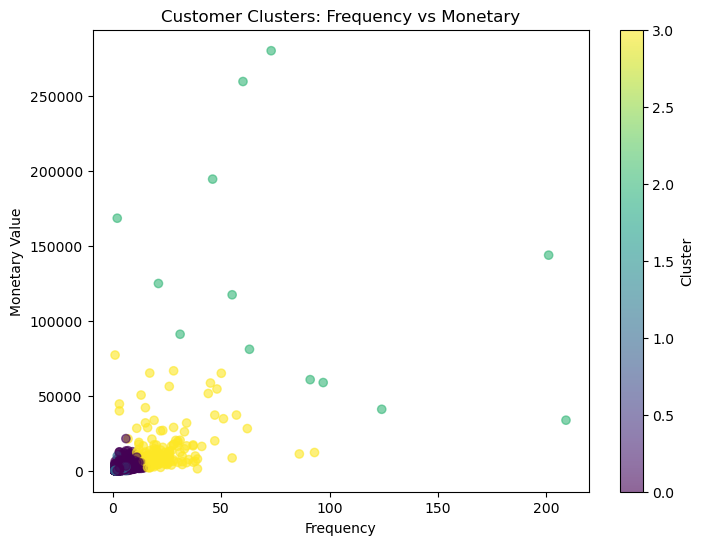

In [47]:
# Frequency vs Monetary

plt.figure(figsize=(8, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.colorbar(label="Cluster")

plt.show()

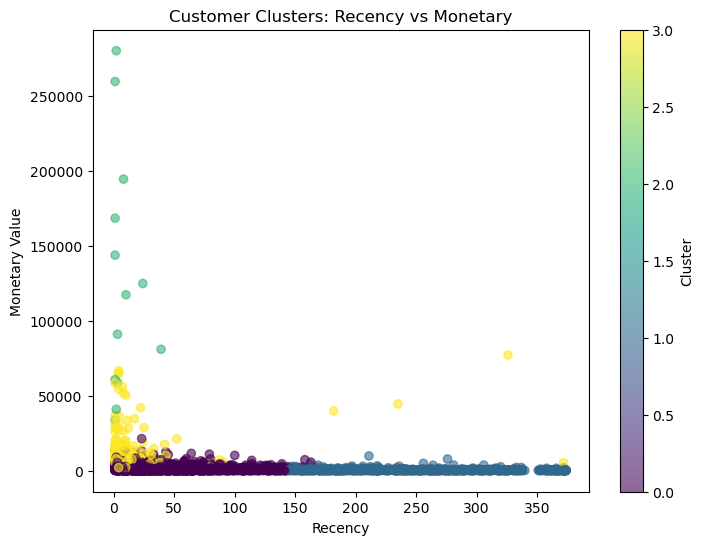

In [48]:
# Recency vs Monetary

plt.figure(figsize=(8, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.colorbar(label="Cluster")

plt.show()

In [49]:
# Identify the most valuable customer cluster

best_cluster = cluster_profile["Monetary"].idxmax()

print("Most valuable customer cluster:", best_cluster)
print("\nDetails of the most valuable cluster:")
print(cluster_profile.loc[best_cluster].round(2))

Most valuable customer cluster: 2

Details of the most valuable cluster:
Recency           7.38
Frequency        82.54
Monetary     127338.31
Name: 2, dtype: float64


In [50]:
# Create customer segment names

def assign_segment(row):
    if row["Recency"] <= rfm["Recency"].median() and row["Frequency"] >= rfm["Frequency"].median() and row["Monetary"] >= rfm["Monetary"].median():
        return "VIP Customers"
    
    elif row["Recency"] <= rfm["Recency"].median() and row["Frequency"] >= rfm["Frequency"].median():
        return "Loyal Customers"
    
    elif row["Recency"] > rfm["Recency"].median() and row["Monetary"] >= rfm["Monetary"].median():
        return "At-Risk High Value"
    
    else:
        return "Occasional Customers"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

print("Customer segments created!")
rfm.head()

Customer segments created!


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,At-Risk High Value
1,12347.0,2,7,4310.00,0,VIP Customers
2,12348.0,75,4,1797.24,0,At-Risk High Value
3,12349.0,19,1,1757.55,0,Occasional Customers
4,12350.0,310,1,334.40,1,Occasional Customers


In [51]:
# Analyze the newly created customer segments

segment_summary = rfm.groupby("Segment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

print("Customer Segment Summary:")
segment_summary

Customer Segment Summary:


,Recency,Frequency,Monetary
Segment,,,
At-Risk High Value,121.81,3.52,1925.22
Loyal Customers,22.36,2.55,429.99
Occasional Customers,155.63,1.35,313.40
VIP Customers,17.51,8.81,4763.06


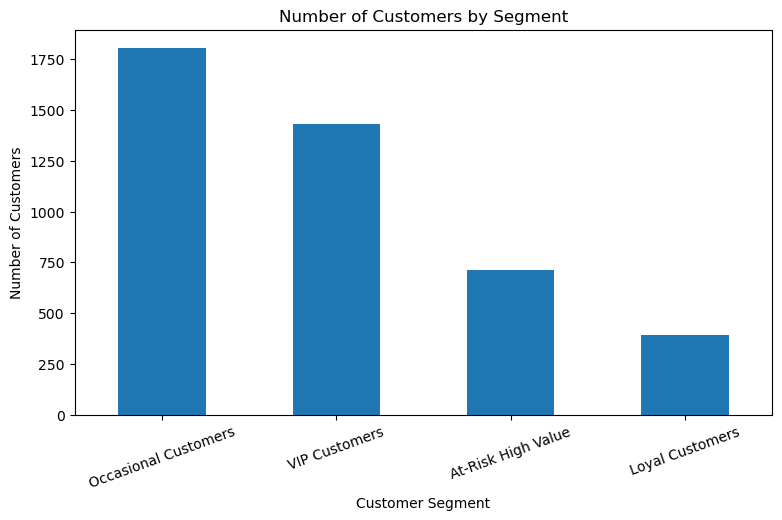

In [52]:
# Number of customers in each segment

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(9, 5))

segment_counts.plot(kind="bar")

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

## Marketing Recommendations

### 1. VIP Customers
These customers purchase frequently and generate high revenue.

**Marketing Strategy:**
- Provide exclusive discounts and rewards.
- Offer loyalty programs.
- Give early access to new products.
- Provide personalized recommendations.

### 2. Loyal Customers
These customers purchase regularly and show strong engagement.

**Marketing Strategy:**
- Encourage repeat purchases.
- Offer loyalty points.
- Send personalized product recommendations.
- Provide bundle offers.

### 3. At-Risk High Value Customers
These customers have previously generated significant revenue but have not purchased recently.

**Marketing Strategy:**
- Send re-engagement emails.
- Provide limited-time discounts.
- Offer personalized promotions.
- Remind them about products they previously purchased.

### 4. Occasional Customers
These customers purchase less frequently and generally have lower spending.

**Marketing Strategy:**
- Use targeted promotional campaigns.
- Offer first/next-purchase discounts.
- Send product recommendations.
- Encourage them to join the loyalty program.

## Key Insights

- RFM analysis was used to understand customer purchasing behavior.
- Customers were segmented using the K-Means clustering algorithm.
- Recency, Frequency, and Monetary value were selected as the main behavioral features.
- StandardScaler was used to normalize the RFM features before clustering.
- The Elbow Method was used to determine a suitable number of clusters.
- Cluster profiles revealed differences in customer purchasing behavior.
- High-value customers should receive personalized rewards and loyalty benefits.
- At-risk customers should be targeted with re-engagement campaigns.
- Occasional customers can be encouraged to purchase more frequently through promotions and recommendations.

## Conclusion

Customer segmentation helps businesses understand different types of customers based on their purchasing behavior. The RFM-based K-Means approach provides useful customer groups that can support targeted marketing strategies, improve customer retention, and increase business revenue.

In [53]:
# Final clustering verification

print("Total customers:", len(rfm))
print("Number of clusters:", rfm["Cluster"].nunique())

print("\nCustomers in each cluster:")
print(rfm["Cluster"].value_counts().sort_index())

print("\nCluster profile:")
print(
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

Total customers: 4338
Number of clusters: 4

Customers in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

Cluster profile:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


In [54]:
# Check for missing values in the final RFM dataset

print("Missing values:")
print(rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster"]].isnull().sum())

Missing values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
Cluster       0
dtype: int64


In [55]:
# Save final customer segmentation results

rfm.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
